In [ ]:
## Project Set up 
import os
import warnings
warnings.filterwarnings("ignore")

os.makedirs("visuals", exist_ok=True)

print("Project folders ready")

Project folders ready


In [ ]:
## Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    silhouette_score
)

print("Libraries imported successfully")

Libraries imported successfully


In [ ]:
## Loading the dataset
df = pd.read_csv("customer_churn.csv")

print("Dataset loaded successfully")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully
Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
## Basic Dataset Inspection 
print("Shape of dataset:", df.shape)
print("\nColumns:\n", df.columns.tolist())

Shape of dataset: (7043, 21)

Columns:
 ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [ ]:
## Dataset Info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [ ]:
## Statistical Summary 
df.describe(include="all")

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [7]:
## Missing Values Check
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [ ]:
## Data cleaning
df.columns = df.columns.str.strip()
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

print("Cleaning complete")
print(df[["tenure", "MonthlyCharges", "TotalCharges"]].isnull().sum())

Cleaning complete
tenure            0
MonthlyCharges    0
TotalCharges      0
dtype: int64


In [9]:
## Create EDA copy
df_plot=df.copy()

print("EDA copy created")

EDA copy created


In [10]:
## Churn counts 
print(df_plot["Churn"].value_counts())
print(df_plot["Churn"].value_counts(normalize=True)*100)

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


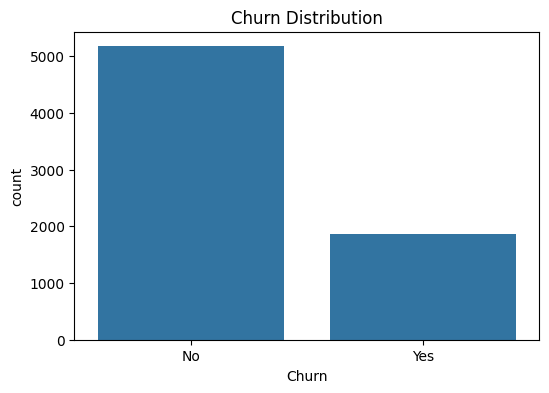

In [11]:
## Churn distribution plot
plt.figure(figsize=(6,4))
sns.countplot(data=df_plot,x="Churn")
plt.title("Churn Distribution")
plt.savefig("visuals/churn_distribution.png",bbox_inches="tight")
plt.show()

<Figure size 800x500 with 0 Axes>

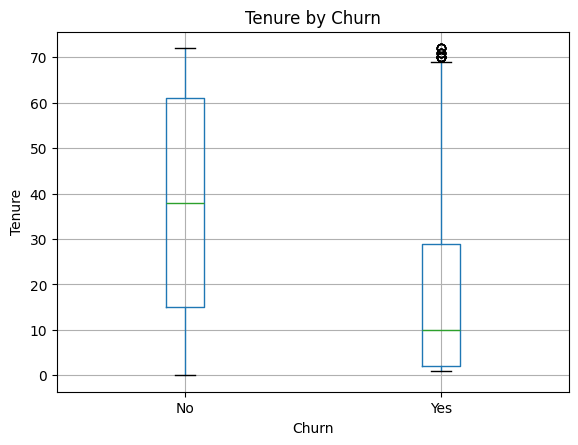

In [12]:
## Tenure by churn
plt.figure(figsize=(8,5))
df_plot.boxplot(column="tenure",by="Churn")
plt.title("Tenure by Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Tenure")
plt.savefig("visuals/tenure_by_churn.png",bbox_inches="tight")
plt.show()

<Figure size 800x500 with 0 Axes>

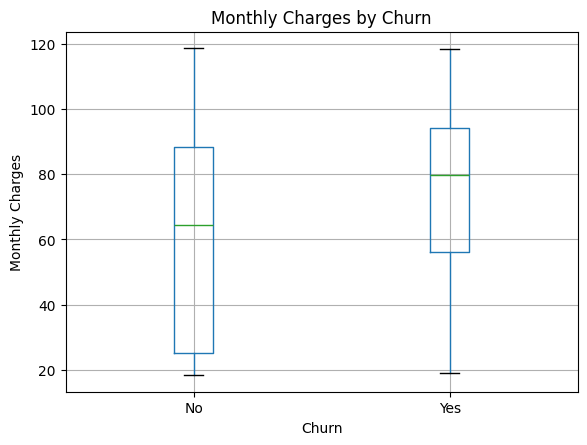

In [13]:
## Monthly charges by churn
plt.figure(figsize=(8,5))
df_plot.boxplot(column="MonthlyCharges",by="Churn")
plt.title("Monthly Charges by Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.savefig("visuals/monthly_charges_by_churn.png",bbox_inches="tight")
plt.show()

<Figure size 800x500 with 0 Axes>

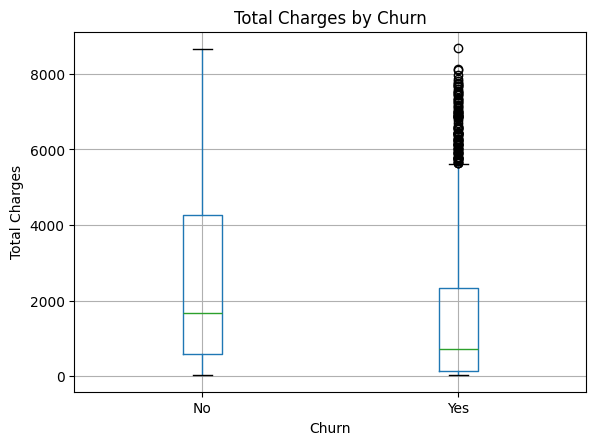

In [14]:
## Total charges by churn
plt.figure(figsize=(8,5))
df_plot.boxplot(column="TotalCharges",by="Churn")
plt.title("Total Charges by Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Total Charges")
plt.savefig("visuals/total_charges_by_churn.png",bbox_inches="tight")
plt.show()

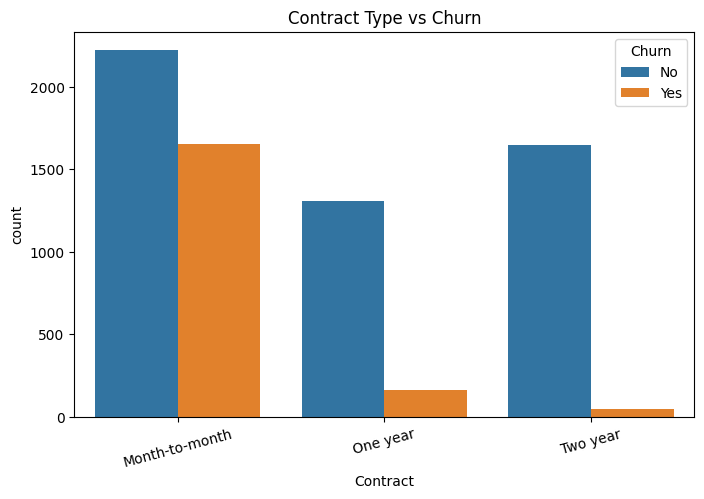

In [15]:
## Contract type vs churn
plt.figure(figsize=(8,5))
sns.countplot(data=df_plot,x="Contract",hue="Churn")
plt.title("Contract Type vs Churn")
plt.xticks(rotation=15)
plt.savefig("visuals/contract_vs_churn.png",bbox_inches="tight")
plt.show()

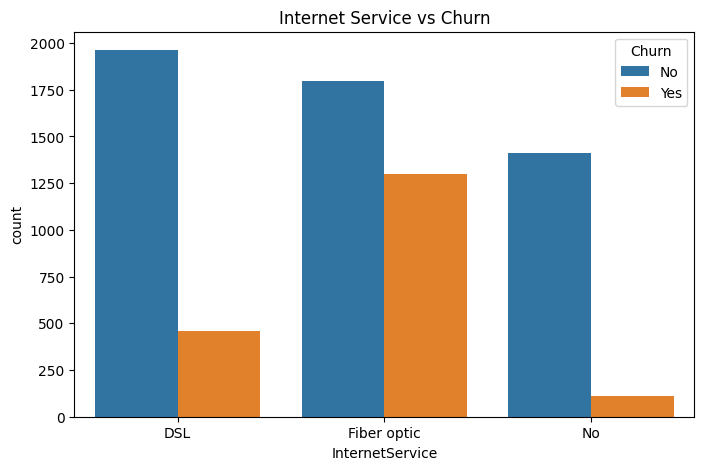

In [16]:
## Internet service vs churn
plt.figure(figsize=(8,5))
sns.countplot(data=df_plot,x="InternetService",hue="Churn")
plt.title("Internet Service vs Churn")
plt.savefig("visuals/internet_service_vs_churn.png",bbox_inches="tight")
plt.show()

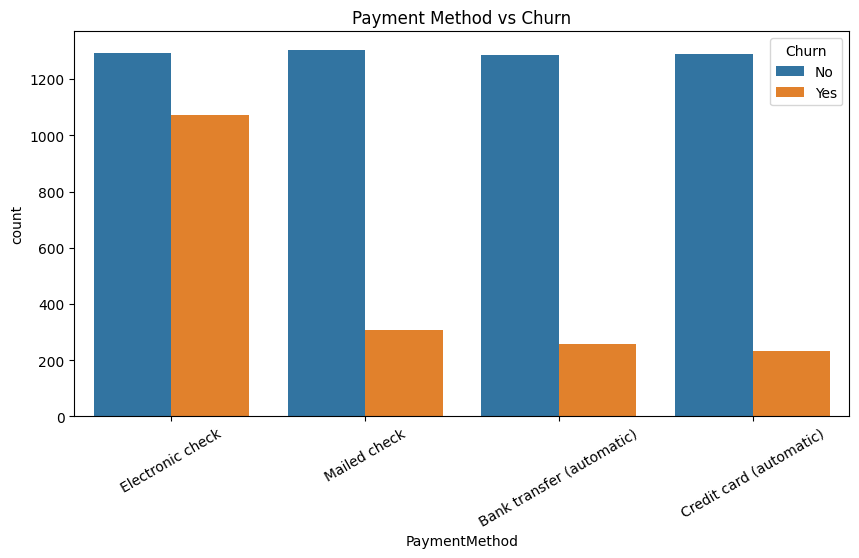

In [17]:
## Payment method vs churn 
plt.figure(figsize=(10,5))
sns.countplot(data=df_plot,x="PaymentMethod",hue="Churn")
plt.title("Payment Method vs Churn")
plt.xticks(rotation=30)
plt.savefig("visuals/payment_method_vs_churn.png",bbox_inches="tight")
plt.show() 

In [18]:
## Encode churn for modeling
df["Churn"]=df["Churn"].map({"Yes":1,"No":0})

print("Churn encoded successfully")
print(df["Churn"].head())

Churn encoded successfully
0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64


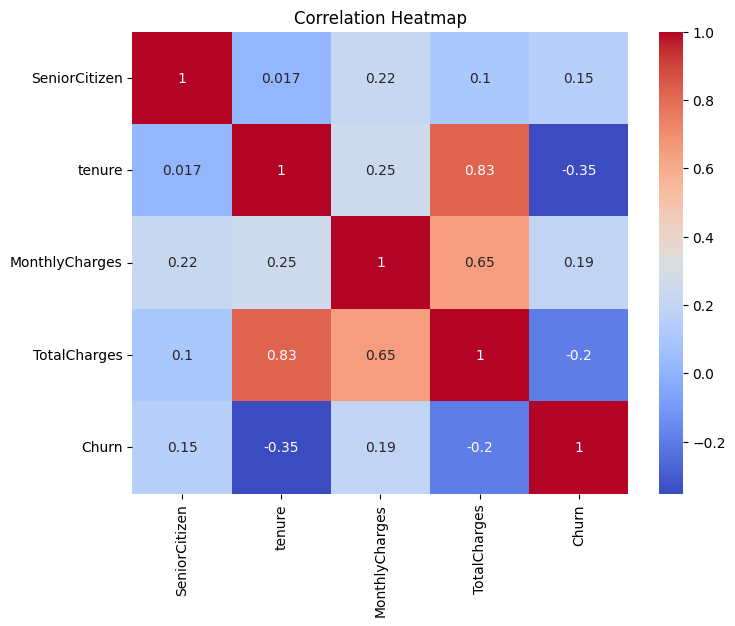

In [19]:
## Correlation heatmap
numeric_cols=df.select_dtypes(include=["int64","float64","int32"]).columns

plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_cols].corr(),annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.savefig("visuals/correlation_heatmap.png",bbox_inches="tight")
plt.show()


In [20]:
## Prepare clustering features
cluster_features= ["tenure","MonthlyCharges","TotalCharges"]
X_cluster=df[cluster_features].copy()

scaler=StandardScaler()
X_cluster_scaled=scaler.fit_transform(X_cluster)

print("Cluster data prepared")
print("NaN count in scaled cluster data:",np.isnan(X_cluster_scaled).sum())

Cluster data prepared
NaN count in scaled cluster data: 0


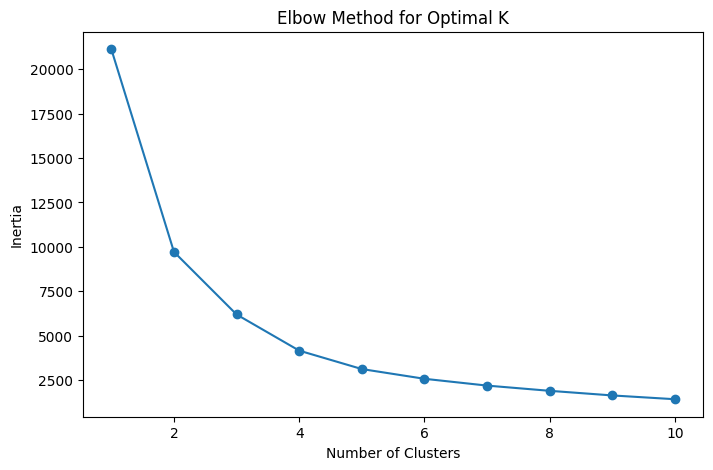

In [22]:
# Elbow method

inertia_values = []

for k in range(1, 11):
    kmeans_test = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_test.fit(X_cluster_scaled)
    inertia_values.append(kmeans_test.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1, 11), inertia_values, marker="o")
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.savefig("visuals/elbow_method.png", bbox_inches="tight")
plt.show()

In [23]:
## Apply KMeans clustering 
kmeans=KMeans(n_clusters=4,random_state=42,n_init=10)
df["Cluster"]=kmeans.fit_predict(X_cluster_scaled)

print("Clusters assigned successfully")
print(df["Cluster"].value_counts().sort_index())

Clusters assigned successfully
Cluster
0    1159
1    1904
2    1704
3    2276
Name: count, dtype: int64


In [24]:
## Silhouette score
sil_score=silhouette_score(X_cluster_scaled,df["Cluster"])
print("Silhouette Score:",round(sil_score,4))

Silhouette Score: 0.472


In [25]:
## Cluster summary
cluster_summary=df.groupby("Cluster")[["tenure","MonthlyCharges","TotalCharges","Churn"]].mean()
cluster_summary 

,tenure,MonthlyCharges,TotalCharges,Churn
Cluster,,,,
0,53.585850,34.920147,1836.581320,0.050043
1,59.530987,93.306224,5548.653887,0.153887
2,10.228873,31.769131,308.956397,0.246479
3,15.424868,80.779657,1253.007239,0.482425


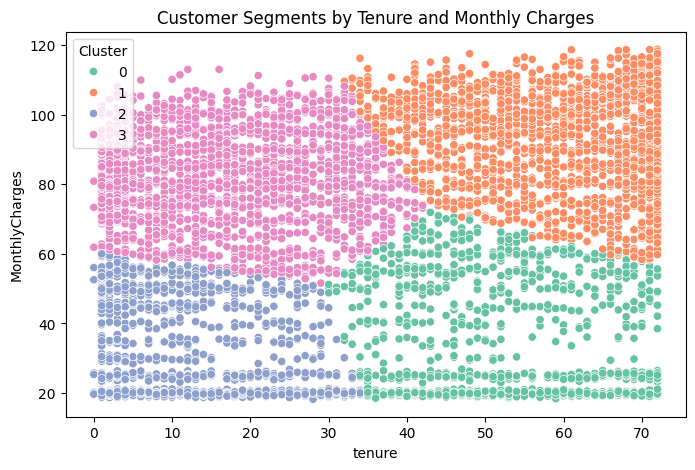

In [26]:
## Cluster scatterplot
plt.figure(figsize=(8,5))
sns.scatterplot(
data=df,
x="tenure",
y="MonthlyCharges",
hue="Cluster",
palette="Set2"
)
plt.title("Customer Segments by Tenure and Monthly Charges")
plt.savefig("visuals/cluster_scatterplot.png",bbox_inches="tight")
plt.show()

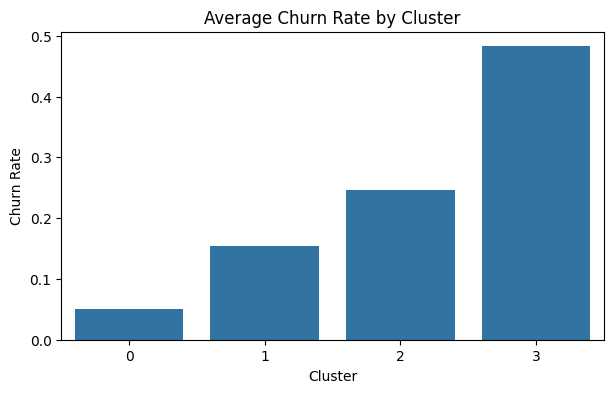

In [27]:
## Churn rate by cluster 
plt.figure(figsize=(7,4))
sns.barplot(x=cluster_summary.index,y=cluster_summary["Churn"])
plt.title("Average Churn Rate by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Churn Rate")
plt.savefig("visuals/churn_rate_by_cluster.png",bbox_inches="tight")
plt.show()

In [29]:
# Prepare model dataset

df_model = df.copy()

if "customerID" in df_model.columns:
    df_model.drop("customerID", axis=1, inplace=True)

df_model = pd.get_dummies(df_model, drop_first=True)

X = df_model.drop("Churn", axis=1)
y = df_model["Churn"]

print("Modeling dataset ready")
print("X shape:", X.shape)
print("y shape:", y.shape)


Modeling dataset ready
X shape: (7043, 31)
y shape: (7043,)


In [30]:
## Train/test split 

X_train,X_test,y_train,y_test=train_test_split(
X,y,
test_size=0.2,
random_state=42,
stratify=y
)

print("Train/test split complete")
print("X_train shape:",X_train.shape)
print("X_test shape:",X_test.shape)

Train/test split complete
X_train shape: (5634, 31)
X_test shape: (1409, 31)


In [31]:
## Train Random Forest 
rf_model=RandomForestClassifier(
n_estimators=200,
max_depth=8,
random_state=42,
class_weight="balanced"
)

rf_model.fit(X_train,y_train)

print("Random Forest model trained successfully")

Random Forest model trained successfully


In [32]:
## Random Forest predictions
y_pred=rf_model.predict(X_test)
y_pred_proba=rf_model.predict_proba(X_test)[:,1]

print("Random Forest predictions complete")

Random Forest predictions complete


In [33]:
## Random Forest evaluation
print("Random Forest Accuracy:",round(accuracy_score(y_test,y_pred),4))
print("Random Forest ROC-AUC:",round(roc_auc_score(y_test,y_pred_proba),4))
print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred))
print("\nClassification Report:\n",classification_report(y_test,y_pred))

Random Forest Accuracy: 0.7587
Random Forest ROC-AUC: 0.8435
Confusion Matrix:
 [[782 253]
 [ 87 287]]

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.76      0.82      1035
           1       0.53      0.77      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.76      0.72      1409
weighted avg       0.80      0.76      0.77      1409



In [34]:
## Train Logistic Regression 
lr_model=LogisticRegression(max_iter=1000,class_weight="balanced")
lr_model.fit(X_train,y_train)

lr_pred=lr_model.predict(X_test)
lr_pred_proba=lr_model.predict_proba(X_test)[:,1]

print("Logistic Regression model trained successfully")

Logistic Regression model trained successfully


In [35]:
## Logistic Regression evaluation
print("Logistic Regression Accuracy:",round(accuracy_score(y_test,lr_pred),4))
print("Logistic Regression ROC-AUC:",round(roc_auc_score(y_test,lr_pred_proba),4))

Logistic Regression Accuracy: 0.7402
Logistic Regression ROC-AUC: 0.8427


In [36]:
## Model comparison table
model_comparison=pd.DataFrame({
"Model": ["Random Forest","Logistic Regression"],
"Accuracy": [
accuracy_score(y_test,y_pred),
accuracy_score(y_test,lr_pred)
    ],
"ROC_AUC": [
roc_auc_score(y_test,y_pred_proba),
roc_auc_score(y_test,lr_pred_proba)
    ]
})

print(model_comparison)

                 Model  Accuracy   ROC_AUC
0        Random Forest  0.758694  0.843517
1  Logistic Regression  0.740241  0.842677


In [37]:
## Save model comparison
model_comparison.to_csv("model_comparison.csv",index=False)
print("Model comparison saved successfully")

Model comparison saved successfully


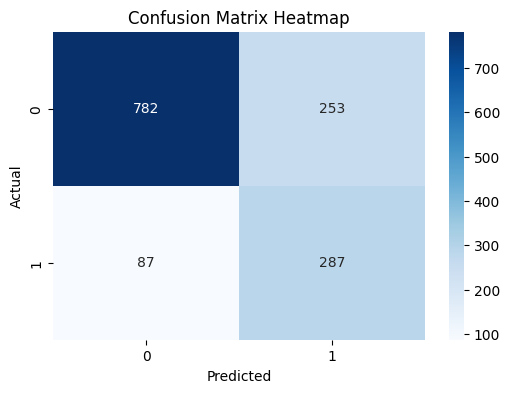

In [38]:
## Confusion matrix heatmap
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt="d",cmap="Blues")
plt.title("Confusion Matrix Heatmap")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("visuals/confusion_matrix.png",bbox_inches="tight")
plt.show()

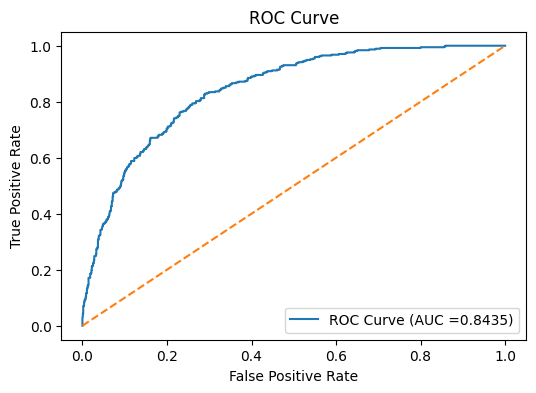

In [39]:
## ROC curve
fpr,tpr,thresholds=roc_curve(y_test,y_pred_proba)

plt.figure(figsize=(6,4))
plt.plot(fpr,tpr,label=f"ROC Curve (AUC ={roc_auc_score(y_test,y_pred_proba):.4f})")
plt.plot([0,1], [0,1],linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.savefig("visuals/roc_curve.png",bbox_inches="tight")
plt.show()

In [40]:
## Feature importance dataframe

feature_importance_df=pd.DataFrame({
"Feature":X.columns,
"Importance":rf_model.feature_importances_
}).sort_values(by="Importance",ascending=False)

print(feature_importance_df.head(15))

                                Feature  Importance
1                                tenure    0.163078
26                    Contract_Two year    0.117925
3                          TotalCharges    0.117313
11          InternetService_Fiber optic    0.079887
4                               Cluster    0.079484
2                        MonthlyCharges    0.079156
29       PaymentMethod_Electronic check    0.057853
25                    Contract_One year    0.041039
14                   OnlineSecurity_Yes    0.028250
20                      TechSupport_Yes    0.020074
13   OnlineSecurity_No internet service    0.019541
27                 PaperlessBilling_Yes    0.016531
19      TechSupport_No internet service    0.015984
15     OnlineBackup_No internet service    0.015141
23  StreamingMovies_No internet service    0.014660


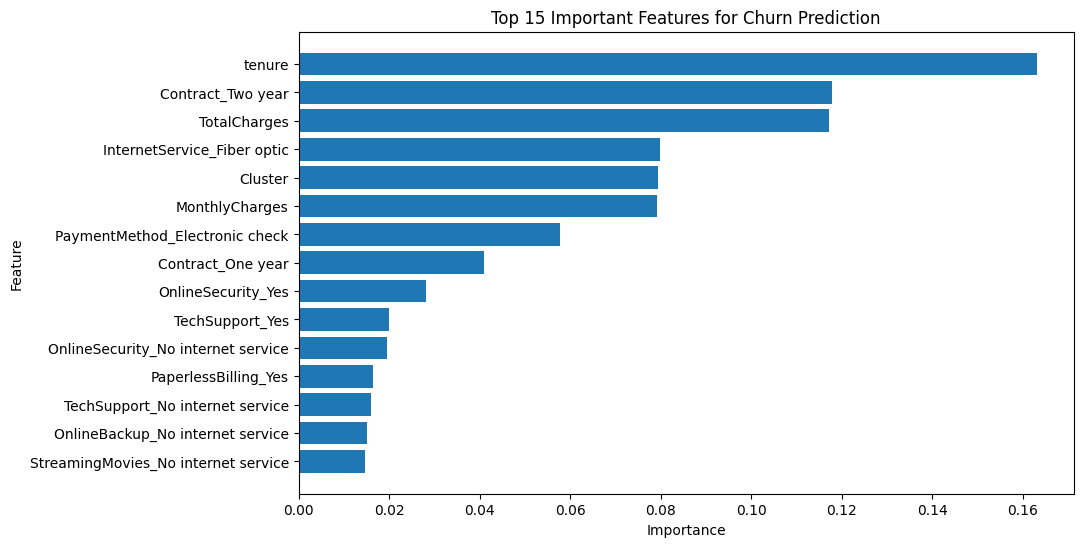

In [41]:
## Feature importance plot 
plt.figure(figsize=(10,6))
plt.barh(feature_importance_df["Feature"].head(15)[::-1],feature_importance_df["Importance"].head(15)[::-1])
plt.title("Top 15 Important Features for Churn Prediction")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.savefig("visuals/feature_importance.png",bbox_inches="tight")
plt.show()

In [42]:
## Save feature importance
feature_importance_df.to_csv("feature_importance.csv",index=False)
print("Feature importance saved successfully")

Feature importance saved successfully


In [43]:
## Create results table
results=X_test.copy()
results["ActualChurn"]=y_test.values
results["PredictedChurn"]=y_pred
results["ChurnProbability"]=y_pred_proba

print("Results table created")
results.head()

Results table created


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Cluster,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,ActualChurn,PredictedChurn,ChurnProbability
437,0,72,114.05,8468.20,1,True,True,True,True,False,...,True,False,True,True,True,False,False,0,0,0.054629
2280,1,8,100.15,908.55,3,False,False,False,True,False,...,True,False,False,True,True,False,False,0,1,0.851409
2235,0,41,78.35,3211.20,3,False,True,True,True,False,...,False,True,False,True,True,False,False,0,0,0.258504
4460,0,18,78.20,1468.75,3,True,True,False,True,False,...,False,False,False,False,False,True,False,0,1,0.587646
3761,0,72,82.65,5919.35,1,False,True,False,True,False,...,True,False,True,True,True,False,False,0,0,0.057002


In [ ]:
## Add risk levels
def risk_level(prob):
    if prob >= 0.75:
        return "High Risk"
    elif prob >= 0.40:
        return "Medium Risk"
    else:
        return "Low Risk"

results["RiskLevel"] = results["ChurnProbability"].apply(risk_level)

results.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Cluster,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,ActualChurn,PredictedChurn,ChurnProbability,RiskLevel
437,0,72,114.05,8468.20,1,True,True,True,True,False,...,False,True,True,True,False,False,0,0,0.054629,Low Risk
2280,1,8,100.15,908.55,3,False,False,False,True,False,...,False,False,True,True,False,False,0,1,0.851409,High Risk
2235,0,41,78.35,3211.20,3,False,True,True,True,False,...,True,False,True,True,False,False,0,0,0.258504,Low Risk
4460,0,18,78.20,1468.75,3,True,True,False,True,False,...,False,False,False,False,True,False,0,1,0.587646,Medium Risk
3761,0,72,82.65,5919.35,1,False,True,False,True,False,...,False,True,True,True,False,False,0,0,0.057002,Low Risk


In [46]:
## Add retention recommendations 
def retention_action(row):
    if row["RiskLevel"] == "High Risk":
        return "Offer discount or retention call"
    elif row["RiskLevel"] == "Medium Risk":
        return "Send engagement email"
    else:
        return "Maintain regular service"

results["RetentionAction"] = results.apply(retention_action, axis=1)

results.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Cluster,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,ActualChurn,PredictedChurn,ChurnProbability,RiskLevel,RetentionAction
437,0,72,114.05,8468.20,1,True,True,True,True,False,...,True,True,True,False,False,0,0,0.054629,Low Risk,Maintain regular service
2280,1,8,100.15,908.55,3,False,False,False,True,False,...,False,True,True,False,False,0,1,0.851409,High Risk,Offer discount or retention call
2235,0,41,78.35,3211.20,3,False,True,True,True,False,...,False,True,True,False,False,0,0,0.258504,Low Risk,Maintain regular service
4460,0,18,78.20,1468.75,3,True,True,False,True,False,...,False,False,False,True,False,0,1,0.587646,Medium Risk,Send engagement email
3761,0,72,82.65,5919.35,1,False,True,False,True,False,...,True,True,True,False,False,0,0,0.057002,Low Risk,Maintain regular service


In [47]:
## Save trained model
with open("rf_churn_model.pkl", "wb") as f:
    pickle.dump(rf_model, f)

print("Trained model saved successfully")

Trained model saved successfully


In [48]:
## Save final outputs
df.to_csv("customer_churn_with_clusters.csv", index=False)
results.to_csv("churn_prediction_results.csv", index=False)
model_comparison.to_csv("model_comparison.csv", index=False)
feature_importance_df.to_csv("feature_importance.csv", index=False)

print("All project outputs saved successfully")

All project outputs saved successfully


In [49]:
## Show final project files
print("Final project files:")
print(os.listdir())

Final project files:
['churn_hybrid_analysis.ipynb', 'churn_hybrid_analysisPL.ipynb', 'churn_prediction_results.csv', 'customer_churn.csv', 'customer_churn_with_clusters.csv', 'feature_importance.csv', 'model_comparison.csv', 'README.md', 'requirements.txt', 'rf_churn_model.pkl', 'visuals']


In [50]:
## Final findings summary
print("Key Findings:")
print("- Customer segmentation was performed using KMeans clustering.")
print("- Clustering quality was evaluated using silhouette score.")
print("- Random Forest and Logistic Regression were compared.")
print("- High-risk churn customers were identified using churn probability.")
print("- Retention recommendations were generated for business use.")

Key Findings:
- Customer segmentation was performed using KMeans clustering.
- Clustering quality was evaluated using silhouette score.
- Random Forest and Logistic Regression were compared.
- High-risk churn customers were identified using churn probability.
- Retention recommendations were generated for business use.
